Illustration of processing pipeline

In [1]:
import numpy as np
from dipy.io.streamline import load_tractogram
from dipy.io.utils import Space
from coloraide import Color
import matplotlib.pylab as pl
import subprocess

In [2]:
path='/home/gui/Documents/Post-doc/code/TractOT/data/'
subject='000000'

# Focus on proj_GMM.py

In [5]:
import sys
sys.path.append('../script/')
from utils import sqrtms,random_MASs
from projection_GMM import proj_GMM_MAS
from distances import distances_aniso
import ot

In [6]:
#Create random MAS
np.random.seed(1)
d=3
nb_MAS=1
nb_MAP=10
k1=8
_,_,_,w1,S1=random_MASs(nb_MAS,nb_MAP,k1,d=3)
w1,S1=w1.reshape(-1,k1),S1.reshape(-1,k1,3,3)
print(w1.shape,S1.shape)

(10, 8) (10, 8, 3, 3)


In [7]:
#proj_GMM_MAS reduce the number of compartment to k2 for each MAP
#k2 size if the maximum of compartment and k2 the number of non null compartment
ksize=6
k2=np.random.randint(1,ksize+1,nb_MAP)
print(k2)
w2,S2=proj_GMM_MAS(k2,ksize,w1,S1)
print(S2.shape,w2.shape)
print(np.count_nonzero(w2,axis=-1))

[5 3 6 5 3 2 5 2 1 2]
(10, 6, 3, 3) (10, 6)
[5 3 6 5 3 2 5 2 1 2]


In [8]:
#For each point, we can compute the distance between the original covariates matrices 
#and covariates matrices with reduced number of compartment
for i in range(nb_MAP):
    C=distances_aniso(S1[i],S2[i,:k2[i]])
    print(ot.emd2([],[],C))

0.5505404482157771
0.7694539066980739
0.43438599700562863
0.8419317772981616
0.9617073074698634
0.8225937740928666
0.9690650221279384
1.5041114347308344
0.9516688477044783
1.1726860022167773


# Add MCM to Tract OT

In [ ]:
n,c=40,30

# Should not be run since it is quite long (~ 5h)
cmd='cd .. && '
cmd+='cd processing && '
cmd+='uv run MCMToTractOT.py'
cmd+=' -t '+path+subject+'/05-Tracts/5downsampled_CST_left_n'+str(n)+'_c'+str(c)+'.vtk'
cmd+=' -c '+path+subject+'/04-AlignedMCM/MCM_avg_aligned/MCM_avg_aligned_' #NOT ON THE DATA FOLDER
cmd+=' -w '+path+subject+'/04-AlignedMCM/MCM_avg_aligned/MCM_avg_aligned_weights.nrrd' #NOT ON THE DATA FOLDER
cmd+=' -s '+path+subject+'/04-AlignedMCM/spatial.nrrd'#NOT ON THE DATA FOLDER
cmd+=' -r '+path+'b0_aligned.nii.gz'
cmd+=' -o '+path+subject+'/06-AugmentedTractsOT/6augmented_CST_left_n'+str(n)+'_c'+str(c)+'.trx'
print(cmd)
subprocess.run(cmd,shell=True)

# Build cores MAS

build cores MAS by clustering of the MAS

In [5]:
n,c=40,30
L=10

# Could be run (~ 5min)
cmd='cd .. && '
cmd+='cd processing && '
cmd+='uv run CoresMAS.py'
cmd+=' -t '+path+subject+'/06-AugmentedTractsOT/6augmented_CST_left_n'+str(n)+'_c'+str(c)+'.trx'
cmd+=' -s '+path+'svm_CST_left.pkl'
cmd+=' -L '+str(L)
cmd+=' -o '+path+subject+'/06-AugmentedTractsOT/7cores_MAS_CST_left_L'+str(L)+'.trx'
print(cmd)
subprocess.run(cmd,shell=True)

cd .. && cd processing && uv run CoresMAS.py -t /home/gui/Documents/Post-doc/code/TractOT/data/000000/06-AugmentedTractsOT/6augmented_CST_left_n40_c30.trx -s /home/gui/Documents/Post-doc/code/TractOT/data/svm_CST_left.pkl -L 10 -o /home/gui/Documents/Post-doc/code/TractOT/data/000000/06-AugmentedTractsOT/7cores_MAS_CST_left_L10.trx


Predict parcellation


/home/gui/Documents/Post-doc/code/TractOT/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


l =  0
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  1
8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  2
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  3
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  4
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  5
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  6
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  7
9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  8
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 
l =  9
8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34

CompletedProcess(args='cd .. && cd processing && uv run CoresMAS.py -t /home/gui/Documents/Post-doc/code/TractOT/data/000000/06-AugmentedTractsOT/6augmented_CST_left_n40_c30.trx -s /home/gui/Documents/Post-doc/code/TractOT/data/svm_CST_left.pkl -L 10 -o /home/gui/Documents/Post-doc/code/TractOT/data/000000/06-AugmentedTractsOT/7cores_MAS_CST_left_L10.trx', returncode=0)

966 10


(np.float64(-10.0), np.float64(110.0), np.float64(-40.0), np.float64(80.0))

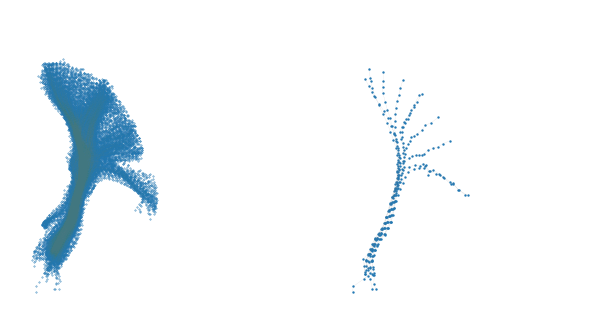

In [16]:
import sys
sys.path.append('../script/')
from from_vtk_to_numpy import vtk_to_numpy_tract_array

tract1 = load_tractogram(
            path+subject+'/06-AugmentedTractsOT/6augmented_CST_left_n'+str(n)+'_c'+str(c)+'.trx',
            reference=path+'b0_aligned.nii.gz',to_space=Space.LPSMM)

tract2 = load_tractogram(
            path+subject+'/06-AugmentedTractsOT/7cores_MAS_CST_left_L'+str(L)+'.trx', 
            reference=path+'b0_aligned.nii.gz',to_space=Space.LPSMM)

nb_streamline1,nb_streamline2=len(tract1.streamlines),len(tract2.streamlines)
print(nb_streamline1,nb_streamline2)
m1=vtk_to_numpy_tract_array(tract1,nb_streamline1)[0]
m2=tract2.streamlines
#m2=vtk_to_numpy_tract_array(tract2,nb_streamline2)[0]

s=1e-1
axis=(0,2)
color='C0'
pl.figure(figsize=(7.5,4))
pl.subplot(1,2,1)
pl.scatter(m1[:,:,axis[0]], m1[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline1):
    pl.plot(m1[i,:,axis[0]], m1[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)
xmin,ymin,sq=-10,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis('off')

pl.subplot(1,2,2)
for i in range(nb_streamline2):
    pl.scatter(m2[i][:,axis[0]], m2[i][:,axis[1]],color=color,s=5*s)
    pl.plot(m2[i][:,axis[0]], m2[i][:,axis[1]],linewidth=.1,color='grey',alpha=.5)
xmin,ymin,sq=-10,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis('off')
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/downsampling_streamline1.png",bbox_inches='tight')

# 23 Compare two cores MAS

In [33]:
from from_trx_to_numpy import trx_to_numpy_tract_list
from distances import distance_cores_svm

subject1='000000'
subject2='000001'

cores1 = load_tractogram(path+subject1+'/06-AugmentedTractsOT/7cores_MAS_CST_left_L'+str(L)+'.trx', reference='same',to_space=Space.LPSMM)
cores2 = load_tractogram(path+subject2+'/06-AugmentedTractsOT/7cores_MAS_CST_left_L'+str(L)+'.trx', reference='same',to_space=Space.LPSMM)

m1,wI1,I1,w1,S1,labels_svm1,_=trx_to_numpy_tract_list(cores1,L)
m2,wI2,I2,w2,S2,labels_svm2,_=trx_to_numpy_tract_list(cores2,L)

cost,_,_,_=distance_cores_svm(m1,m2,wI1,wI2,I1,I2,w1,w2,S1,S2,labels_svm1,labels_svm2,alpha=0.5)

print(cost)

12.30533591367979
